In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# DATA LOADING

In [2]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct


In [6]:
# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        # Read the header information (16 bytes)
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read the image data, reshape it to (num_images, rows * cols)
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        # Read the header information (8 bytes)
        magic, num_labels = struct.unpack(">II", f.read(8))
        # Read the label data
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Loading training data
train_images = load_images('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/train-images-idx3-ubyte')
train_labels = load_labels('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte')
test_labels = load_labels('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


In [14]:
import matplotlib.pyplot as plt

# Function to display a single image
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

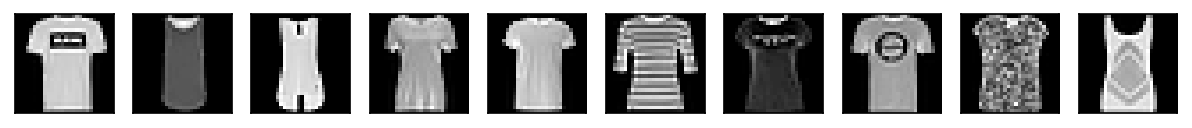

'label 1'

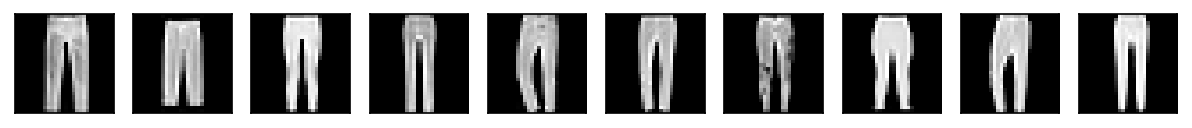

'label 2'

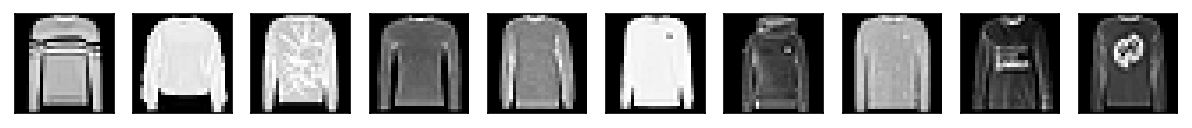

'label 3'

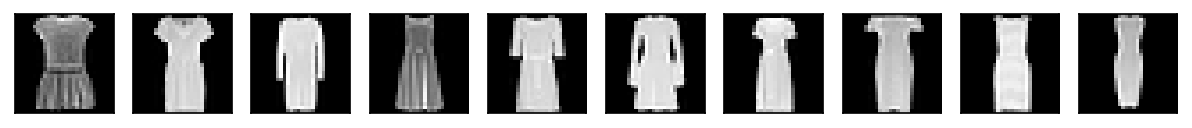

'label 4'

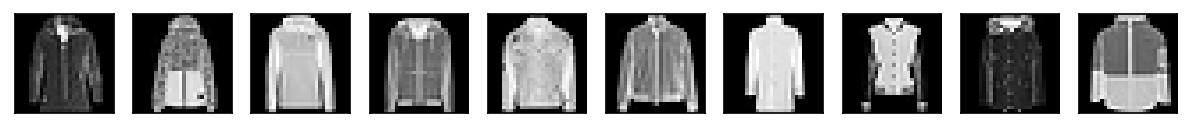

'label 5'

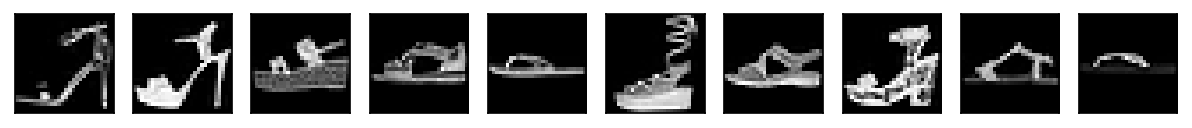

'label 6'

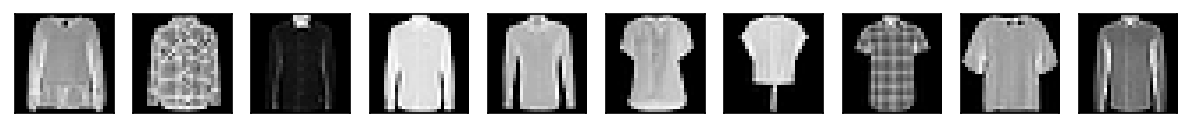

'label 7'

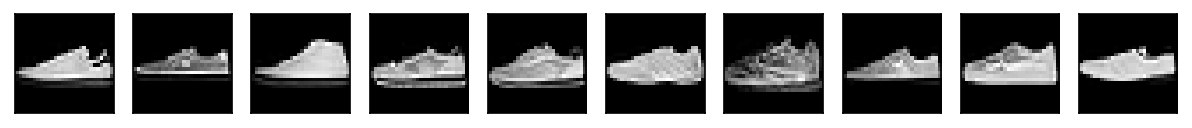

'label 8'

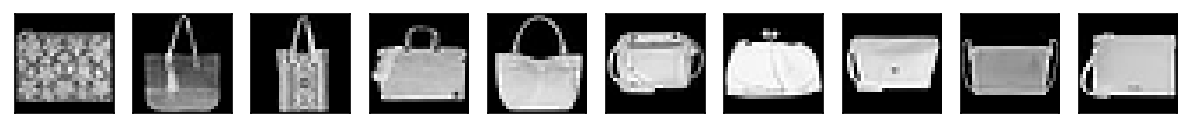

'label 9'

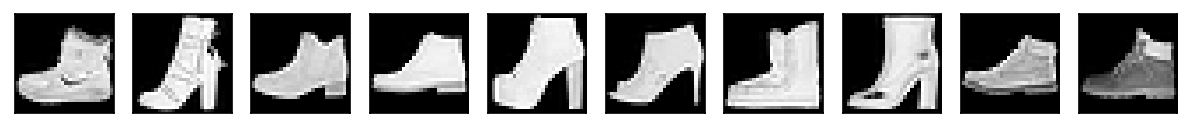

In [9]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

# PREPROCESSING

In [37]:
from sklearn.model_selection import train_test_split

# Split training data into training and validation sets (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

print("Training set size:", len(train_images))
print("Validation set size:", len(val_images))


Training set size: 48000
Validation set size: 12000


In [41]:
# Nomalize data, scale to range between 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)


In [16]:
train_images_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Drop and Rotation if possible and necessary...
import torchvision.transforms as transforms

# Define data augmentation
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28)
])

### Perform basic exploratory data analysis (EDA) to understand the

*   Mục danh sách
*   Mục danh sách

distribution of classes and visualize some sample images.

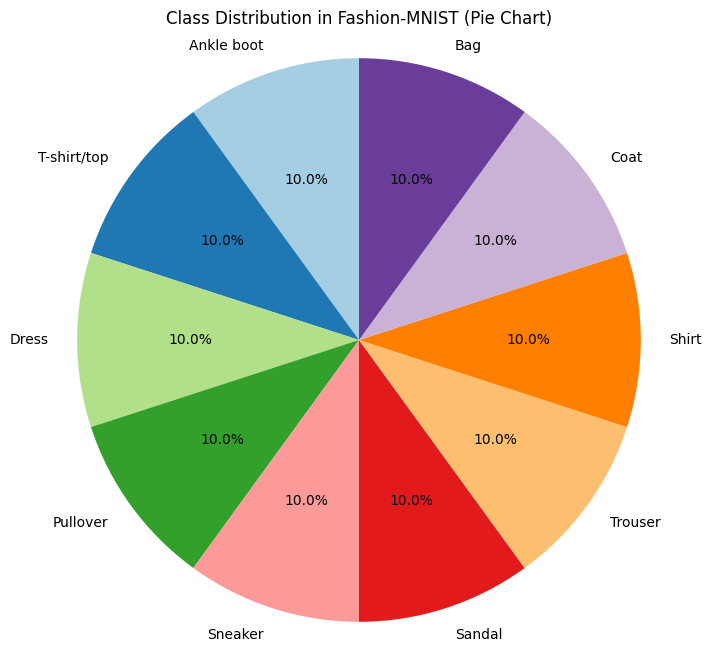

In [19]:
import matplotlib.pyplot as plt
from collections import Counter

# List of class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Function to create a pie chart for class distribution
def pie_chart_class_distribution(labels):
    # Count occurrences of each class label
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    # Plot the pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Class Distribution in Fashion-MNIST (Pie Chart)')
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
    plt.show()

# Example usage with train labels
pie_chart_class_distribution(train_labels)


The number of each layer is the same => the dataset is balanced

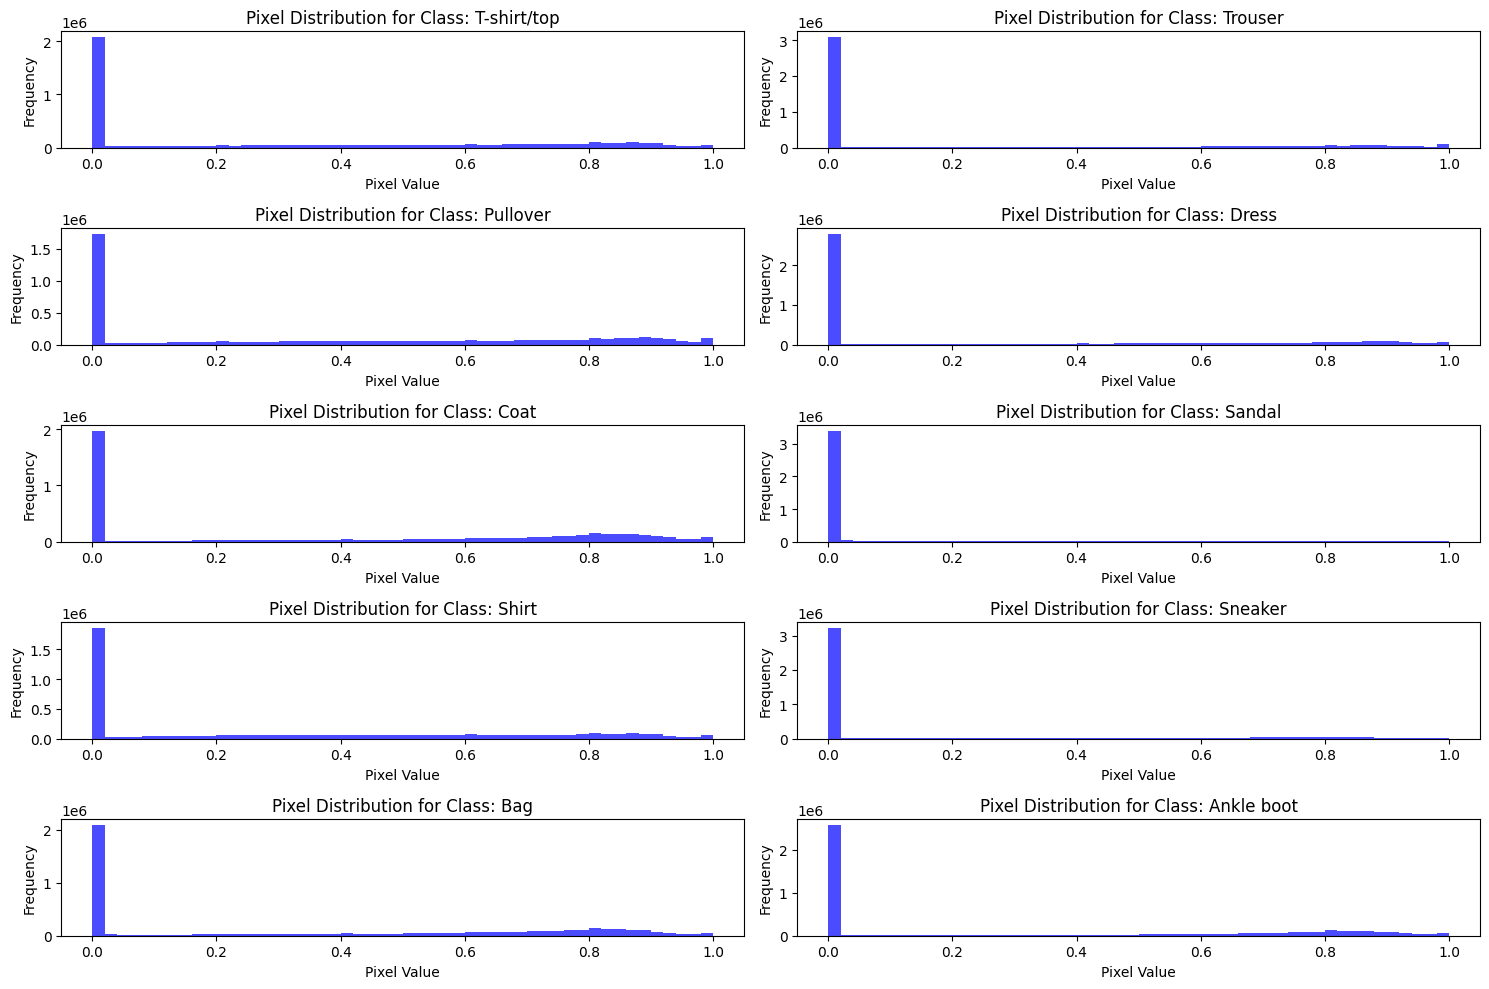

In [27]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images_scaled, train_labels, class_names)


We can see values .0 that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.

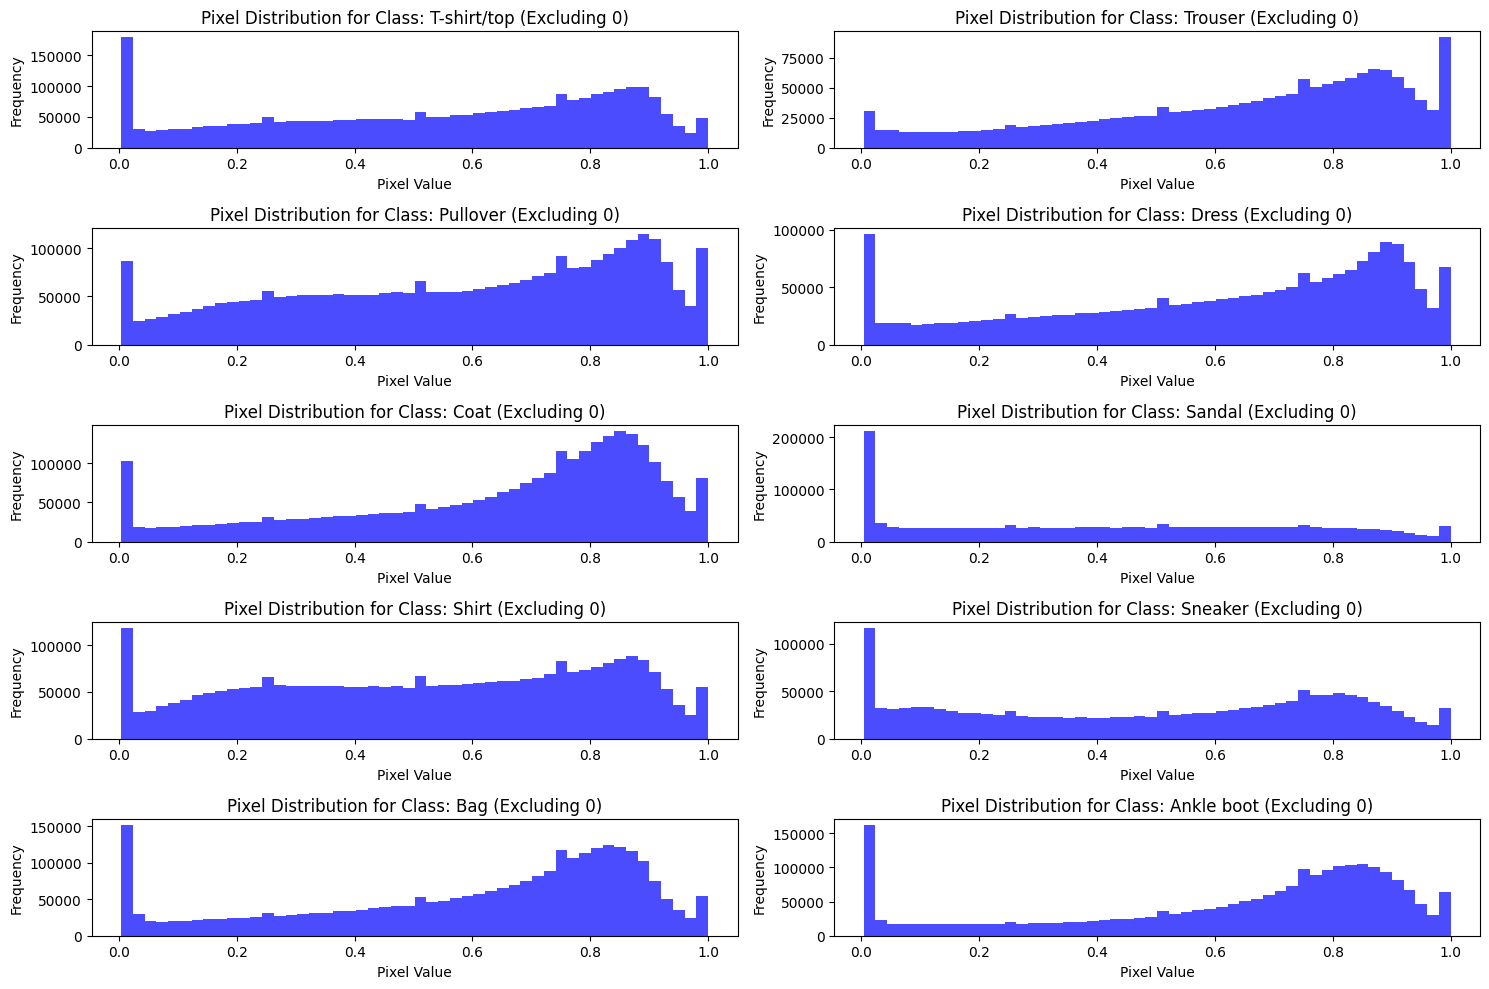

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images_scaled, train_labels, class_names)

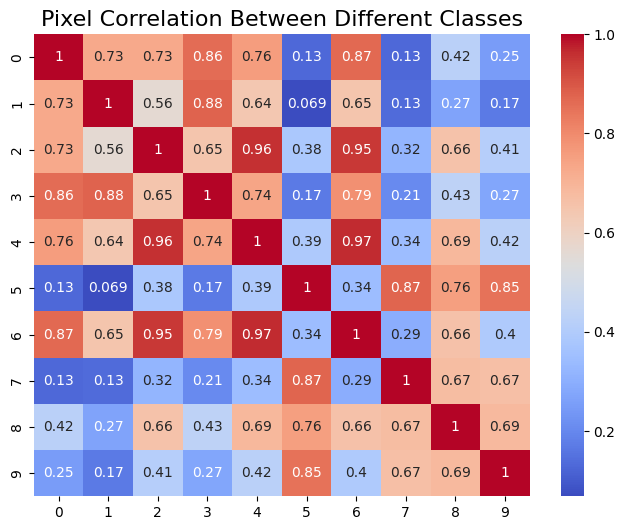

In [21]:
 # Tính toán ma trận tương quan giữa các lớp
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_images[i])

# Tính toán ảnh trung bình của từng lớp
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Tính toán ma trận tương quan giữa các lớp
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

# Vẽ ma trận tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes.

In [43]:
# Tiền xử lý HoG với kích thước cell là [4,4] (theo nghiên cứu)
def apply_hog(images):
    hog_features = []
    for image in images:
        image_reshaped = image.reshape(28, 28)  # Fashion MNIST có kích thước 28x28
        hog_feature = hog(image_reshaped, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False)
        hog_features.append(hog_feature)
    return np.array(hog_features)

train_hog = apply_hog(train_images_scaled)
val_hog = apply_hog(val_images_scaled)
test_hog = apply_hog(test_images_scaled)

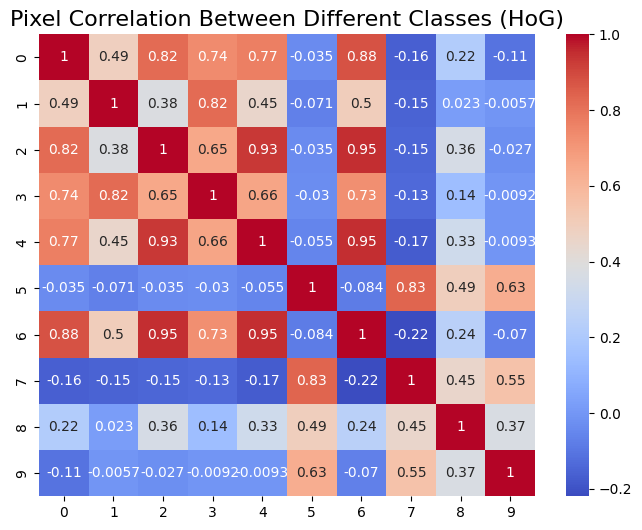

In [44]:
# Tính toán ma trận tương quan giữa các lớp như trước
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_hog[i])

mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

# Vẽ ma trận tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes (HoG)", fontsize=16)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='ovr', max_iter=1000)
model.fit(train_hog, train_labels)

val_predictions = model.predict(val_hog)
print("Report val:")
print(classification_report(val_labels, val_predictions))